# Part A - MDS-UPDRS Part Analysis

### Test the sum of each part. Ie: test Part 1 (rows 3-15) , test Part 2 (rows 16- 28), and test Part 3 (29-61)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import palettable.wesanderson as wes

import sys
sys.path.insert(0 , './../MDS-UPDRS_Analysis/')
import distributions
from distributions import *

%load_ext autoreload
%autoreload 2

# Get Idiopathic IDs

In [2]:
meta = pd.read_csv('./../../data/PPMI/MO-LLM/PPMI_META_LINKAGE.csv')
idiopathic_ids = meta[np.logical_and(meta['Subgroup'] == 'Sporadic' , meta['CONCOHORT_DEFINITION'] == "Parkinson's Disease")]['PATNO'].unique()

# Specify Event IDs for which Genomic Data is Available

In [3]:
events = ['BL' , 'V02' , 'V04' , 'V06' , 'V08' , 'V10' , 'V12' , 'V14' , 'V16']

all_events = ['SC', 'BL', 'V01', 'V02', 'V03', 'V04', 'V05',
'V06', 'V07', 'V08', 'V09', 'V10', 'V11', 'V12',
'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19',
'ST', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25'
]

# MDS-UPDRS Part I

In [4]:
p1_1 = pd.read_csv('./../Assesment_Exams/MDS-UPDRS_Part_I_21Jan2025.csv')
p1_1_filt = p1_1.loc[: , ['PATNO' , 'EVENT_ID'] + [col for col in p1_1.columns if 'NP1' in col]]

p1_2 = pd.read_csv('./../Assesment_Exams/MDS-UPDRS_Part_I_Patient_Questionnaire_21Jan2025.csv')
p1_2_filt = p1_2.loc[: , ['PATNO' , 'EVENT_ID'] + [col for col in p1_2.columns if 'NP1' in col]]

p1_final = pd.merge(p1_1_filt , p1_2_filt , on = ['PATNO' , 'EVENT_ID'])
p1_final['NP1TOT'] = p1_final['NP1RTOT'] + p1_final['NP1PTOT']
p1_final = p1_final.drop(['NP1RTOT' , 'NP1PTOT'] , axis=1)
p1_final = p1_final.replace(101, np.nan).drop_duplicates()

p1_final = p1_final[p1_final['PATNO'].isin(idiopathic_ids)]

In [5]:
all_tmpt = pd.DataFrame({'EVENT_ID' : np.tile(events , len(p1_final['PATNO'].unique())) , 'PATNO' : np.repeat(p1_final['PATNO'].unique() , len(events))})

p1_final = p1_final[p1_final['EVENT_ID'].isin(all_events)]
p1_impute = pd.merge(all_tmpt , p1_final , on = ['PATNO' , 'EVENT_ID'] , how = 'outer')
p1_impute['EVENT_ID'] = pd.Categorical(p1_impute['EVENT_ID'] , categories=all_events , ordered=True)

In [6]:
all_tmpt = pd.DataFrame({'EVENT_ID' : np.tile(events , len(p1_final['PATNO'].unique())) , 'PATNO' : np.repeat(p1_final['PATNO'].unique() , len(events))})

p1_final = p1_final[p1_final['EVENT_ID'].isin(all_events)]
p1_impute = pd.merge(all_tmpt , p1_final , on = ['PATNO' , 'EVENT_ID'] , how = 'outer')
p1_impute['EVENT_ID'] = pd.Categorical(p1_impute['EVENT_ID'] , categories=all_events , ordered=True)

for patno in p1_impute['PATNO'].unique() : 
    df = p1_impute[p1_impute['PATNO'] == patno].copy()
    df['Temp_ID'] = df['EVENT_ID'].cat.codes.values
    for i in range(1, len(df) - 1):
        if df.iloc[i].isnull().any():  # Check if NaN exists in the row
            prev_row = df.iloc[i - 1]
            next_row = df.iloc[i + 1]
    
            # Check if the previous and next rows are consecutive
            if (prev_row['Temp_ID'] + 1 == df.iloc[i]['Temp_ID'] 
                    and next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID']):
                df.iloc[i] = df.iloc[i].fillna(df.iloc[[i - 1, i + 1]].mean(numeric_only=True))
            elif prev_row['Temp_ID'] + 1 == df.iloc[i]['Temp_ID'] : 
                df.iloc[i] = df.iloc[i].fillna(df.iloc[i - 1])
            elif next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID'] : 
                df.iloc[i] = df.iloc[i].fillna(df.iloc[i + 1])
    
    df = df.drop('Temp_ID', axis=1)

    p1_impute[p1_impute['PATNO'] == patno] = df.copy()

p1 = p1_impute[np.logical_and(p1_impute['PATNO'].isin(idiopathic_ids) , p1_impute['EVENT_ID'].isin(events))]

# Gamma Distribution

In [9]:
for feat in p1.columns[2:] : 
    p1.pivot_table(values = feat , columns = 'EVENT_ID' , index = 'PATNO' , observed=False).to_csv(f'./../Labels/MDS-UPDRS_{feat}_Scores.csv')

In [ ]:
p1_label = pd.DataFrame()

for event in p1['EVENT_ID'].unique() : 
    print(f'Distribution for event {event}')
    data = p1[p1['EVENT_ID'] == event].set_index('PATNO')['NP1TOT']
    p1_label = pd.concat([p1_label , pd.DataFrame(labels , index=data.index , columns=[event])] , axis=1)

Distribution for event BL
There are 610 assessments at this event
Estimated alpha (shape): 2.1240322752769667
Estimated beta (rate): 0.35349216493038693


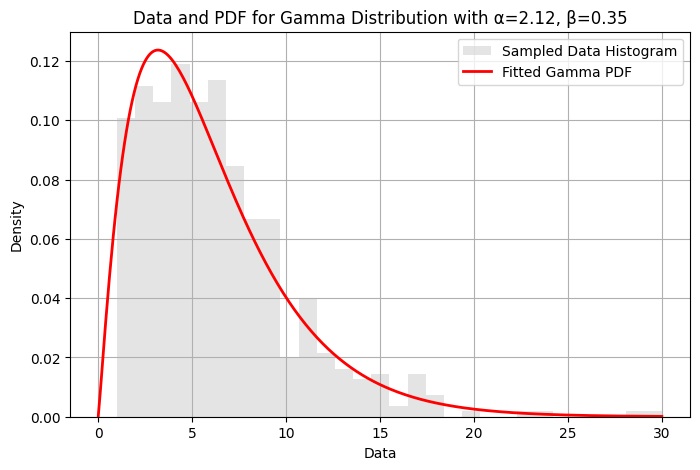

Gamma AIC : 3056.9811032913176
Distribution for event V02
There are 610 assessments at this event
Estimated alpha (shape): 2.1035984631393254
Estimated beta (rate): 0.32959057286494103


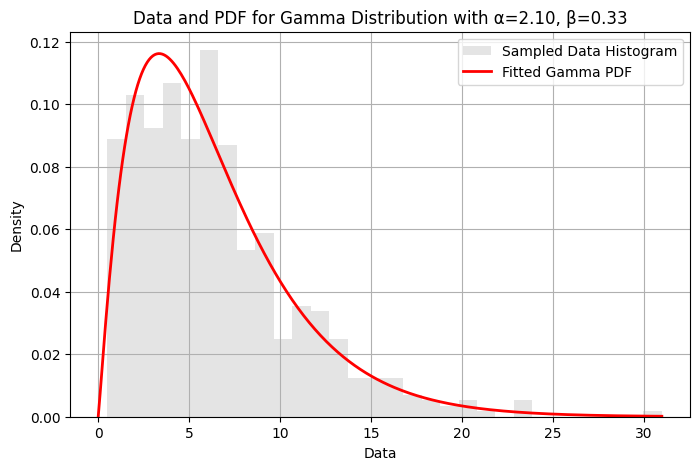

Gamma AIC : 3015.2699270885323
Distribution for event V04
There are 610 assessments at this event
Estimated alpha (shape): 2.2483965168643847
Estimated beta (rate): 0.3226163142849104


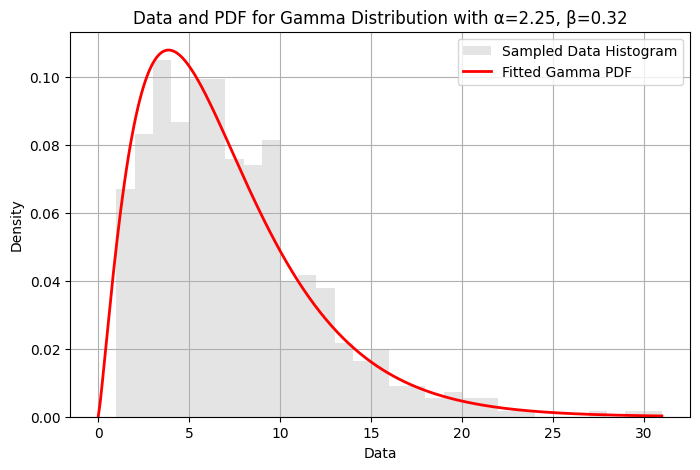

Gamma AIC : 3089.732823934596
Distribution for event V06
There are 610 assessments at this event
Estimated alpha (shape): 2.2261493334718594
Estimated beta (rate): 0.2936577095741897


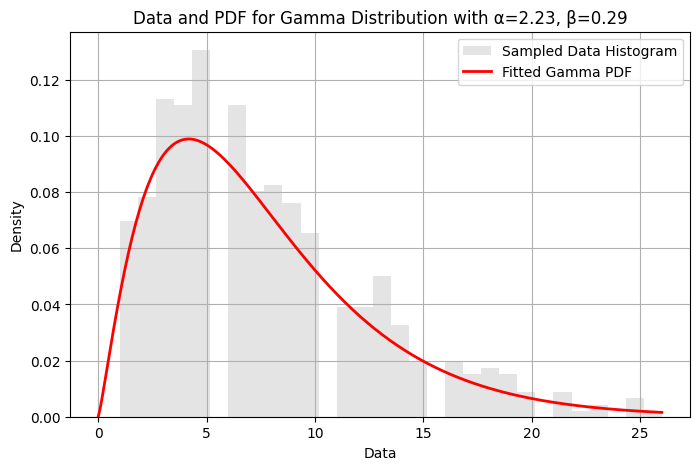

Gamma AIC : 3174.7220911073928
Distribution for event V08
There are 610 assessments at this event
Estimated alpha (shape): 2.4169782520894327
Estimated beta (rate): 0.2867987021099764


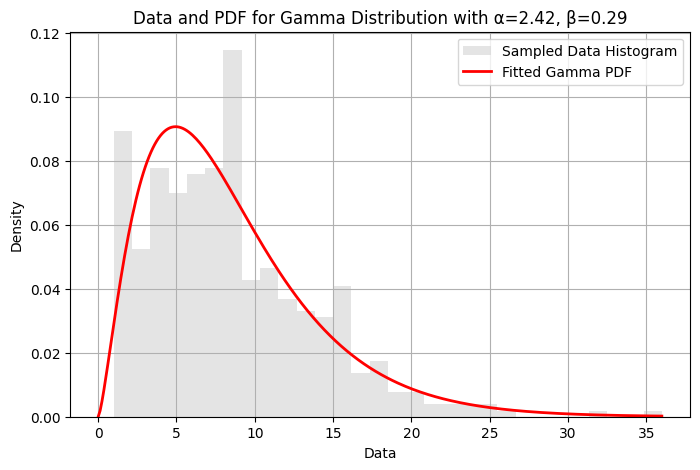

Gamma AIC : 2611.6188672391204
Distribution for event V10
There are 610 assessments at this event
Estimated alpha (shape): 2.611802426764858
Estimated beta (rate): 0.27762938024098655


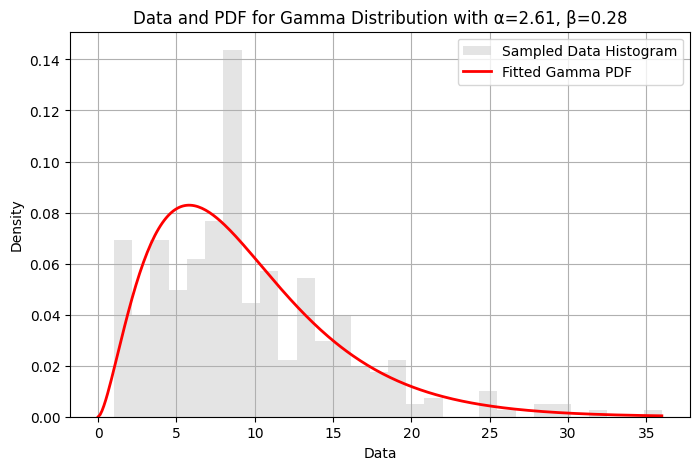

Gamma AIC : 2107.793418546441
Distribution for event V12
There are 610 assessments at this event
Estimated alpha (shape): 2.1662051324012945
Estimated beta (rate): 0.22532139946117175


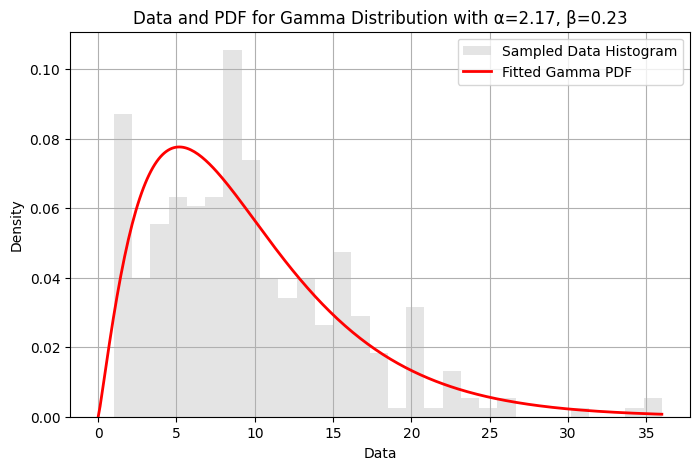

Gamma AIC : 2034.1799071493183
Distribution for event V14
There are 610 assessments at this event
Estimated alpha (shape): 2.6908771259836173
Estimated beta (rate): 0.2661618454776004


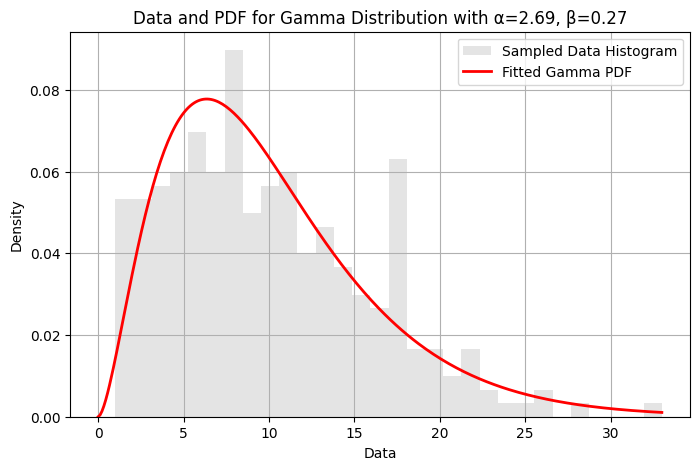

Gamma AIC : 1753.3858910733734
Distribution for event V16
There are 610 assessments at this event
Estimated alpha (shape): 3.0097369957552673
Estimated beta (rate): 0.2820569023304525


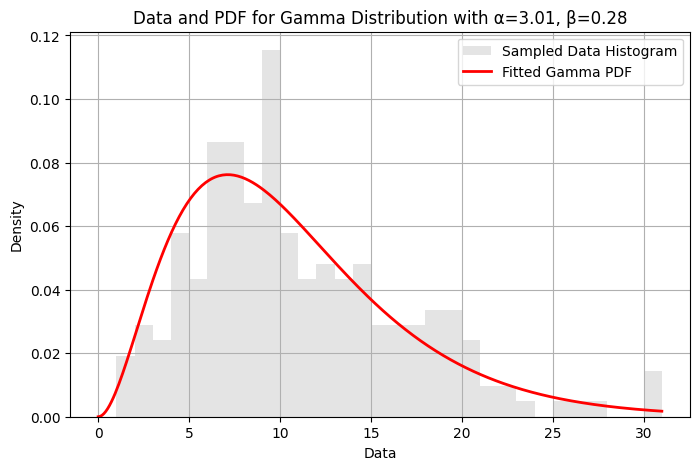

Gamma AIC : 1299.9510475915695


In [7]:
p1_label = pd.DataFrame()

for event in p1['EVENT_ID'].unique() : 
    print(f'Distribution for event {event}')
    data = p1[p1['EVENT_ID'] == event].set_index('PATNO')['NP1TOT']
    n_events = data.shape[0]
    print(f'There are {n_events} assessments at this event')
    data_filt = data[data>0]
    alpha_est , beta_est = fit_gamma_distribution(data_filt)
    aic_score = calculate_gamma_aic(data_filt, (alpha_est , beta_est))
    labels = gamma_significance_classify(data , alpha_est , beta_est , 'Worse' , thresh=0.2)
    p1_label = pd.concat([p1_label , pd.DataFrame(labels , index=data.index , columns=[event])] , axis=1)
    print(f'Gamma AIC : {aic_score}')

In [8]:
p1_label.to_csv('./../Labels/PartA_Part1_Labels.csv')

Distribution for event BL
There are 610 assessments at this event
Estimated mu: 1.5397113041453792
Estimated sigma: 0.7571816908282949


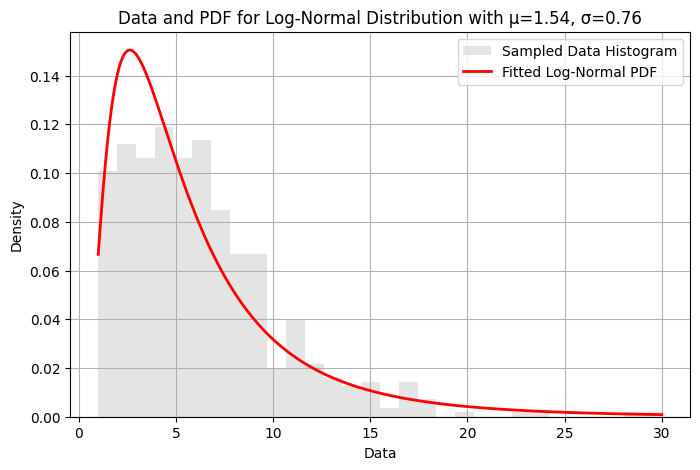

Log-Normal AIC : 3081.211471312751
Distribution for event V02
There are 610 assessments at this event
Estimated mu: 1.5974214609356387
Estimated sigma: 0.766007804812963


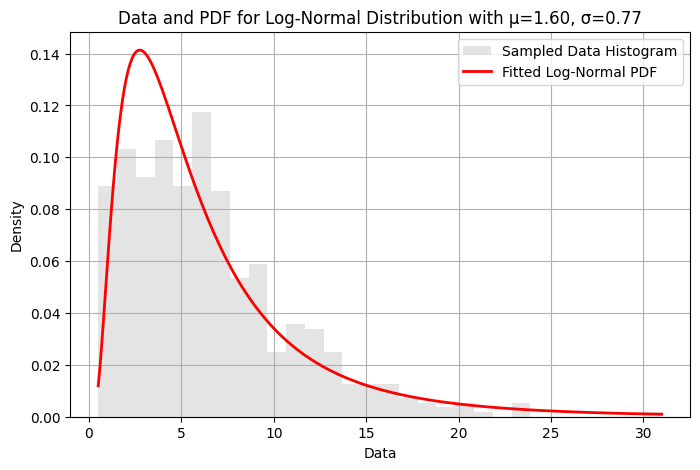

Log-Normal AIC : 3045.275563993459
Distribution for event V04
There are 610 assessments at this event
Estimated mu: 1.7029439826061281
Estimated sigma: 0.7405698721202532


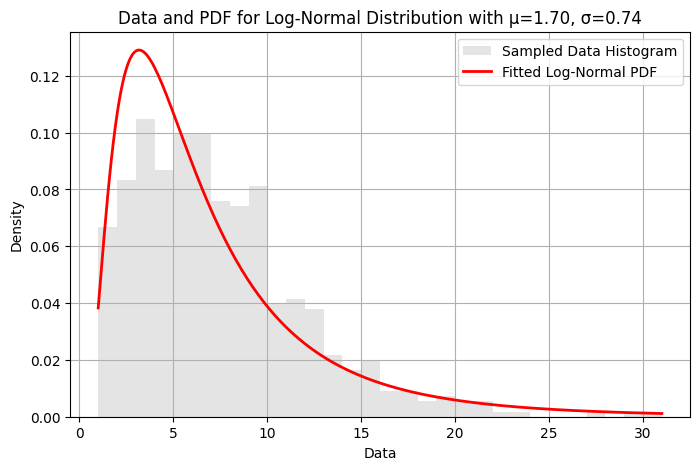

Log-Normal AIC : 3124.6312298698404
Distribution for event V06
There are 610 assessments at this event
Estimated mu: 1.7845070508367336
Estimated sigma: 0.7465291450889402


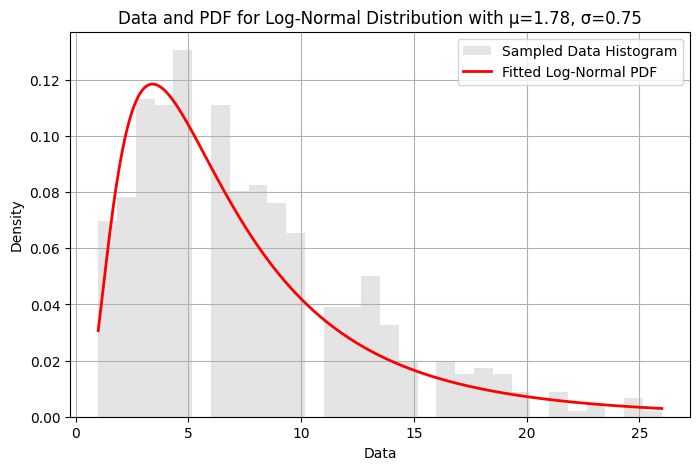

Log-Normal AIC : 3212.0597034945195
Distribution for event V08
There are 610 assessments at this event
Estimated mu: 1.9105849755121345
Estimated sigma: 0.7150526685193395


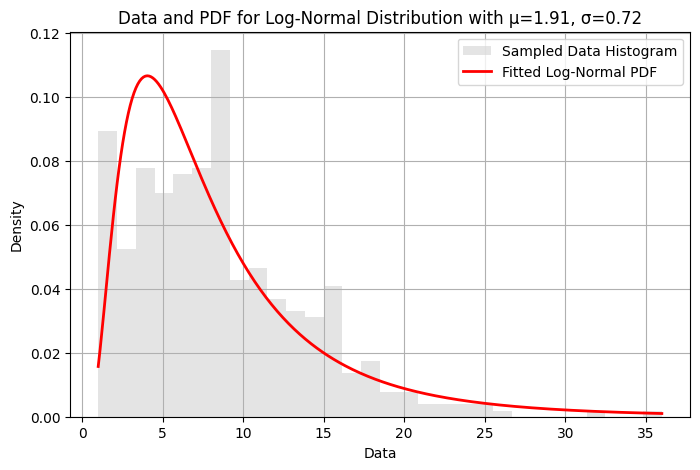

Log-Normal AIC : 2644.817749006851
Distribution for event V10
There are 610 assessments at this event
Estimated mu: 2.038022047193845
Estimated sigma: 0.6800309725734176


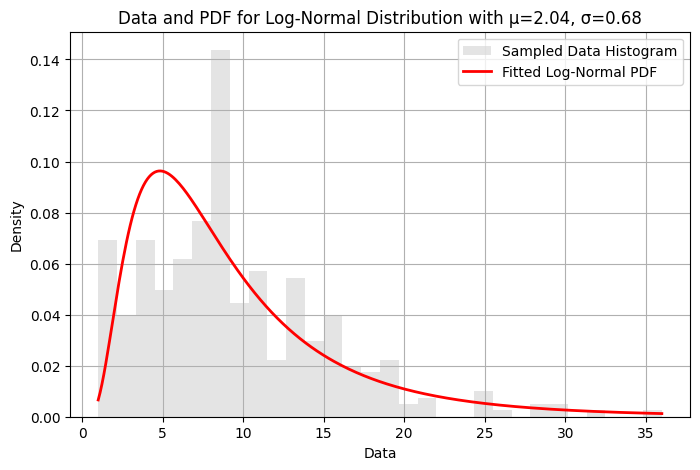

Log-Normal AIC : 2129.3698074483736
Distribution for event V12
There are 610 assessments at this event
Estimated mu: 2.0149734000840027
Estimated sigma: 0.7795246610657341


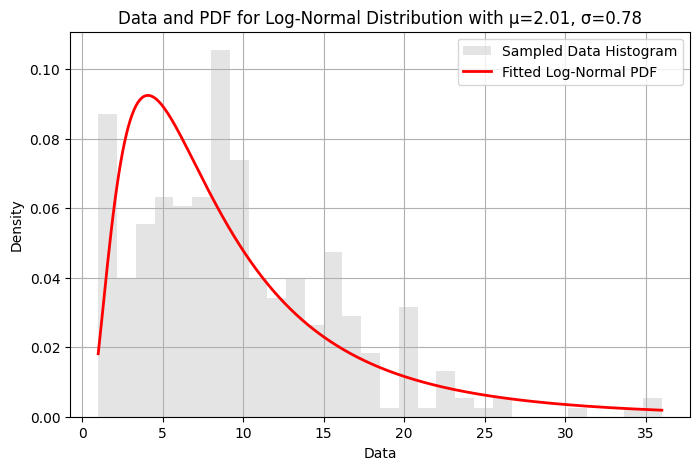

Log-Normal AIC : 2074.1466365677957
Distribution for event V14
There are 610 assessments at this event
Estimated mu: 2.1163459912098355
Estimated sigma: 0.6837233162238523


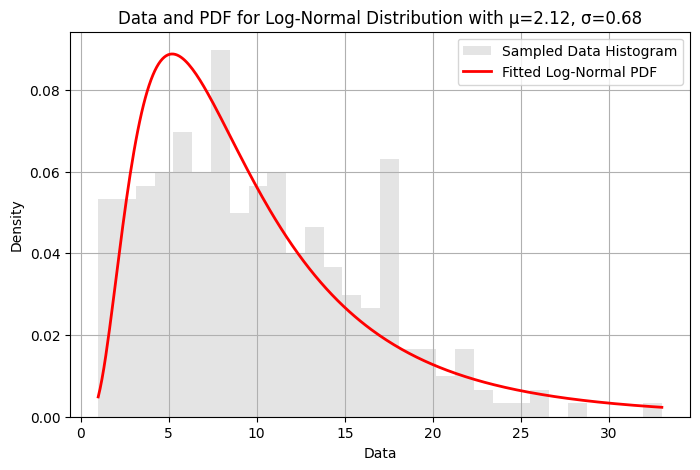

Log-Normal AIC : 1783.466565769343
Distribution for event V16
There are 610 assessments at this event
Estimated mu: 2.1922689536914453
Estimated sigma: 0.6437173323302878


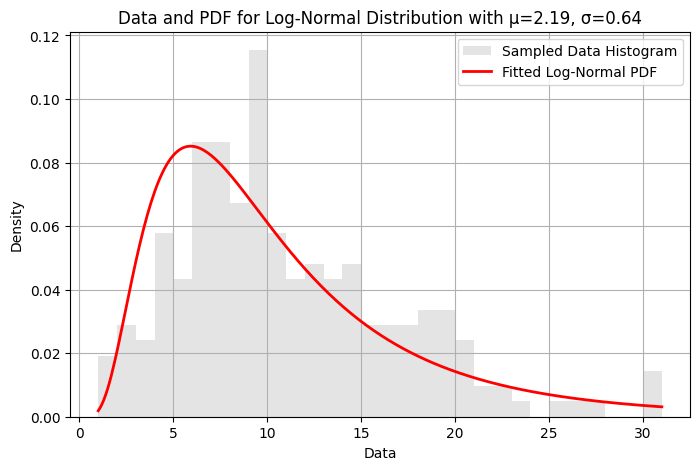

Log-Normal AIC : 1323.0161518327059


In [9]:
for event in p1['EVENT_ID'].unique() : 
    print(f'Distribution for event {event}')
    data = p1[p1['EVENT_ID'] == event]['NP1TOT']
    n_events = data.shape[0]
    print(f'There are {n_events} assessments at this event')
    data = data[data>0]
    alpha_est , beta_est = fit_log_normal_distribution(data)
    aic_score = calculate_log_normal_aic(data, (alpha_est , beta_est))
    print(f'Log-Normal AIC : {aic_score}')

# MDS-UPDRS Part II

In [18]:
p2 = pd.read_csv('./../Assesment_Exams/MDS_UPDRS_Part_II__Patient_Questionnaire_21Jan2025.csv')
p2_final = p2.loc[: , ['PATNO' , 'EVENT_ID'] + [col for col in p2.columns if 'NP2' in col]]
p2_final = p2_final.replace(101, np.nan).drop_duplicates()

p2_final = p2_final[p2_final['PATNO'].isin(idiopathic_ids)]

In [19]:
all_tmpt = pd.DataFrame({'EVENT_ID' : np.tile(events , len(p2_final['PATNO'].unique())) , 'PATNO' : np.repeat(p2_final['PATNO'].unique() , len(events))})

p2_final = p2_final[p2_final['EVENT_ID'].isin(all_events)]
p2_impute = pd.merge(all_tmpt , p2_final , on = ['PATNO' , 'EVENT_ID'] , how = 'outer')
p2_impute['EVENT_ID'] = pd.Categorical(p2_impute['EVENT_ID'] , categories=all_events , ordered=True)

for patno in p2_impute['PATNO'].unique() : 
    df = p2_impute[p2_impute['PATNO'] == patno].copy()
    df['Temp_ID'] = df['EVENT_ID'].cat.codes.values
    for i in range(1, len(df) - 1):
        if df.iloc[i].isnull().any():  # Check if NaN exists in the row
            prev_row = df.iloc[i - 1]
            next_row = df.iloc[i + 1]
    
            # Check if the previous and next rows are consecutive
            if (prev_row['Temp_ID'] + 1 == df.iloc[i]['Temp_ID'] 
                    and next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID']):
                df.iloc[i] = df.iloc[i].fillna(df.iloc[[i - 1, i + 1]].mean(numeric_only=True))
    
    df = df.drop('Temp_ID', axis=1)

    p2_impute[p2_impute['PATNO'] == patno] = df.copy()

p2 = p2_impute[np.logical_and(p2_impute['PATNO'].isin(idiopathic_ids) , p2_impute['EVENT_ID'].isin(events))]

## Gamma Distribution

In [20]:
p2.pivot_table(values = 'NP2PTOT' , columns = 'EVENT_ID' , index = 'PATNO' , observed=False).to_csv('./../Labels/PartA_Part2_Scores.csv')

Distribution for event BL
There are 610 assessments at this event
Estimated alpha (shape): 1.8880523285378648
Estimated beta (rate): 0.3225199778573959


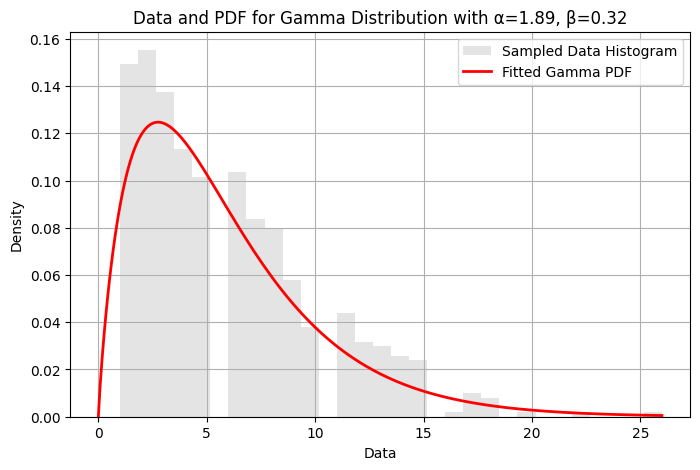

Gamma AIC : 3220.9692745458033
Distribution for event V02
There are 610 assessments at this event
Estimated alpha (shape): 1.970050011864889
Estimated beta (rate): 0.28658183550207605


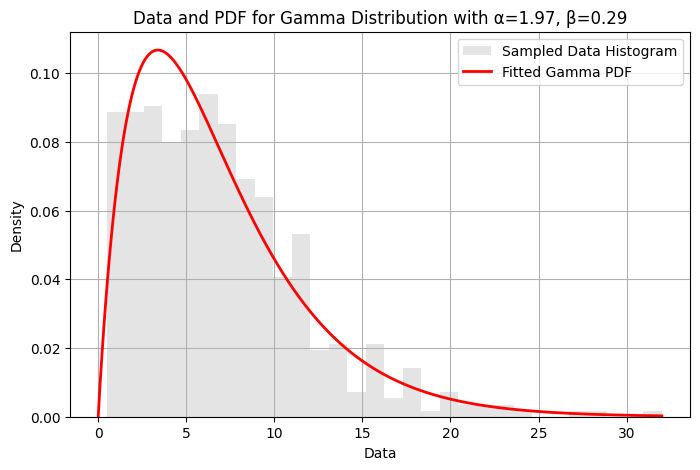

Gamma AIC : 3028.6021743893966
Distribution for event V04
There are 610 assessments at this event
Estimated alpha (shape): 2.1109880968721337
Estimated beta (rate): 0.28894446527780726


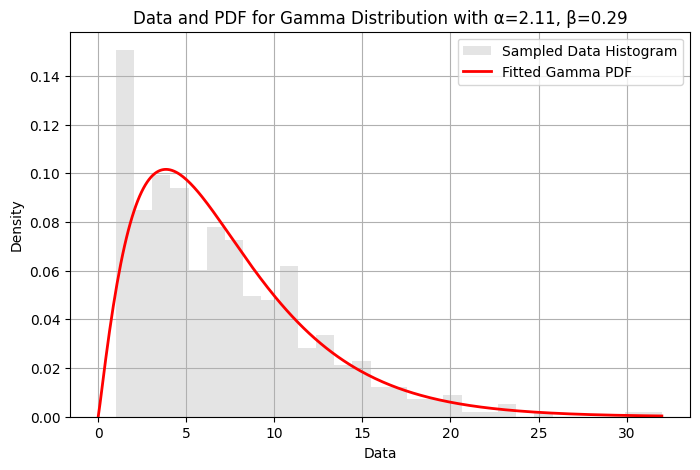

Gamma AIC : 3123.548410375437
Distribution for event V06
There are 610 assessments at this event
Estimated alpha (shape): 1.9923207442245165
Estimated beta (rate): 0.252730652235036


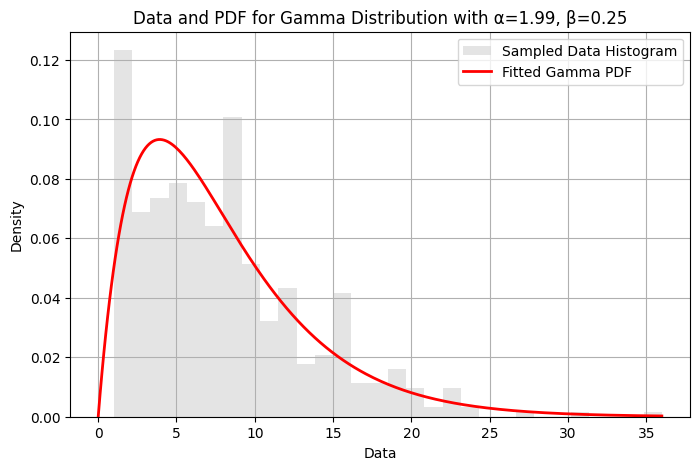

Gamma AIC : 3160.4068031084425
Distribution for event V08
There are 610 assessments at this event
Estimated alpha (shape): 2.2596701381841084
Estimated beta (rate): 0.2565126642249751


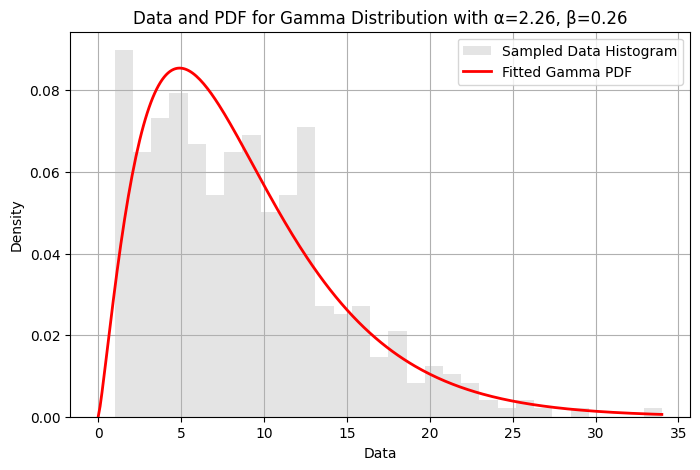

Gamma AIC : 2633.741149967736
Distribution for event V10
There are 610 assessments at this event
Estimated alpha (shape): 2.2316407478630134
Estimated beta (rate): 0.22676240064736583


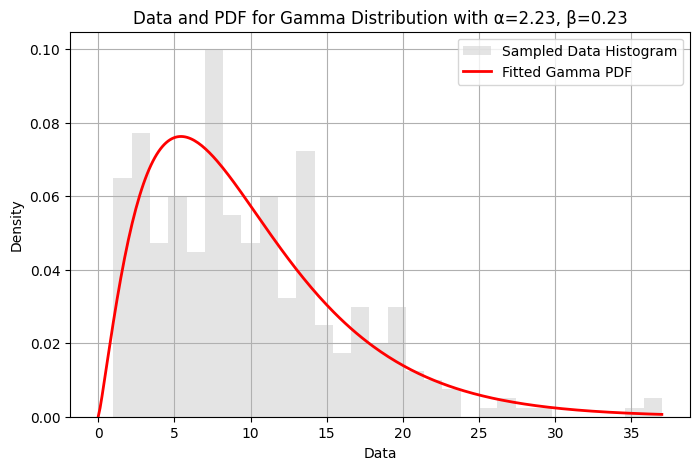

Gamma AIC : 2099.811096796696
Distribution for event V12
There are 610 assessments at this event
Estimated alpha (shape): 2.0293008866831306
Estimated beta (rate): 0.2013734967714661


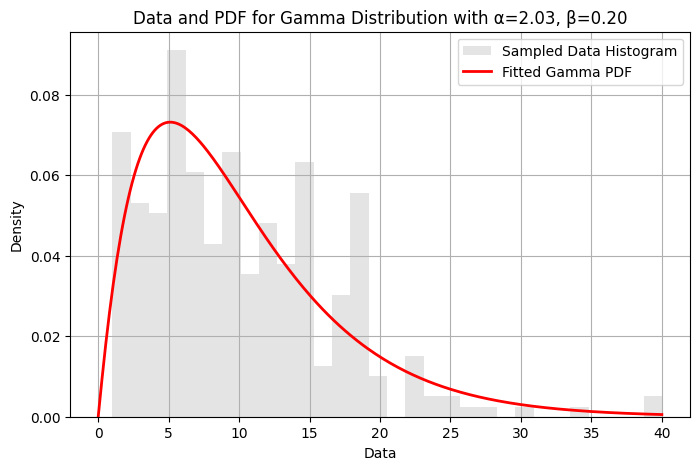

Gamma AIC : 1943.5877252516188
Distribution for event V14
There are 610 assessments at this event
Estimated alpha (shape): 2.684030088705786
Estimated beta (rate): 0.22444540996542314


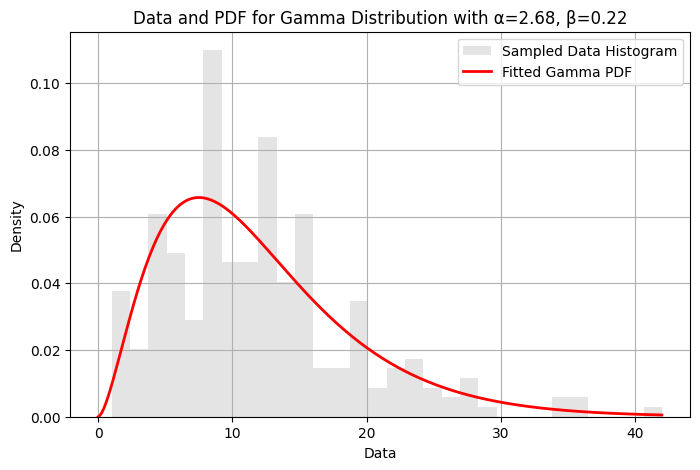

Gamma AIC : 1658.9079125995218
Distribution for event V16
There are 610 assessments at this event
Estimated alpha (shape): 3.1389005567593604
Estimated beta (rate): 0.24623910078322592


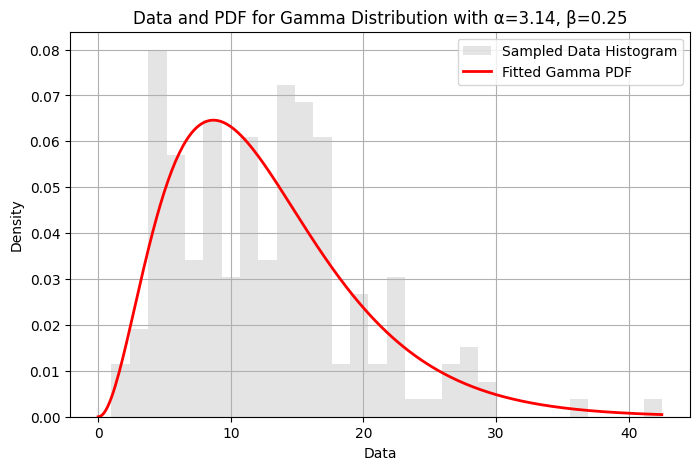

Gamma AIC : 1249.4165566986148


In [12]:
p2_label = pd.DataFrame()

for event in p2['EVENT_ID'].unique() : 
    print(f'Distribution for event {event}')
    data = p2[p2['EVENT_ID'] == event].set_index('PATNO')['NP2PTOT']
    n_events = data.shape[0]
    print(f'There are {n_events} assessments at this event')
    data_filt = data[data>0]
    alpha_est , beta_est = fit_gamma_distribution(data_filt)
    aic_score = calculate_gamma_aic(data_filt, (alpha_est , beta_est))
    labels = gamma_significance_classify(data , alpha_est , beta_est , 'Worse' , thresh=0.2)
    p2_label = pd.concat([p2_label , pd.DataFrame(labels , index=data.index , columns=[event])] , axis=1)
    print(f'Gamma AIC : {aic_score}')

In [13]:
p2_label

,BL,V02,V04,V06,V08,V10,V12,V14,V16
PATNO,,,,,,,,,
3001,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse
3002,Worse,Worse,Worse,Worse,Worse,Worse,Worse,Worse,Worse
3003,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,NaN
3006,Not Worse,Not Worse,Worse,NaN,NaN,NaN,NaN,NaN,NaN
3007,Not Worse,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
160231,Not Worse,Not Worse,Not Worse,Not Worse,NaN,NaN,NaN,NaN,NaN
161236,Not Worse,Not Worse,Not Worse,Not Worse,NaN,NaN,NaN,NaN,NaN
162929,Worse,Worse,Worse,Worse,NaN,NaN,NaN,NaN,NaN


In [14]:
p2_label.to_csv('./../Labels/PartA_Part2_Labels.csv')

# MDS-UPDRS Part III

In [21]:
p3 = pd.read_csv('./../Assesment_Exams/MDS-UPDRS_Part_III_21Jan2025.csv')
p3 = p3[p3['PDSTATE'].isin([np.nan , 'OFF'])]
p3_final = p3.loc[: , ['PATNO' , 'EVENT_ID'] + [col for col in p3.columns if 'NP3' in col]]
p3_final = p3_final.replace(101, np.nan).drop_duplicates()

p3_final = p3_final[p3_final['PATNO'].isin(idiopathic_ids)]

p3_meta = p3.loc[ : , ['PATNO' , 'EVENT_ID' , 'PDTRTMNT' , 'PDSTATE' , 'HRPOSTMED' , 'HRDBSON', 'HRDBSOFF', 'PDMEDYN', 'DBSYN', 'ONOFFORDER', 'OFFEXAM', 'OFFNORSN', 'DBSOFFTM', 'ONEXAM', 'ONNORSN' ]]

In [22]:
all_tmpt = pd.DataFrame({'EVENT_ID' : np.tile(events , len(p3_final['PATNO'].unique())) , 'PATNO' : np.repeat(p3_final['PATNO'].unique() , len(events))})

p3_final = p3_final[p3_final['EVENT_ID'].isin(all_events)]
p3_impute = pd.merge(all_tmpt , p3_final , on = ['PATNO' , 'EVENT_ID'] , how = 'outer')
p3_impute['EVENT_ID'] = pd.Categorical(p3_impute['EVENT_ID'] , categories=all_events , ordered=True)

for patno in p3_impute['PATNO'].unique() : 
    df = p3_impute[p3_impute['PATNO'] == patno].copy()
    df['Temp_ID'] = df['EVENT_ID'].cat.codes.values
    for i in range(1, len(df) - 1):
        if df.iloc[i].isnull().any():  # Check if NaN exists in the row
            prev_row = df.iloc[i - 1]
            next_row = df.iloc[i + 1]
    
            # Check if the previous and next rows are consecutive
            if (prev_row['Temp_ID'] + 1 == df.iloc[i]['Temp_ID'] 
                    and next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID']):
                df.iloc[i] = df.iloc[i].fillna(df.iloc[[i - 1, i + 1]].mean(numeric_only=True))
    
    df = df.drop('Temp_ID', axis=1)

    p3_impute[p3_impute['PATNO'] == patno] = df.copy()

p3 = p3_impute[np.logical_and(p3_impute['PATNO'].isin(idiopathic_ids) , p3_impute['EVENT_ID'].isin(events))]

## Gamma Distribution

In [23]:
p3.pivot_table(values = 'NP3TOT' , columns = 'EVENT_ID' , index = 'PATNO' , observed=False).to_csv('./../Labels/PartA_Part3_Scores.csv')

Distribution for event BL
There are 610 assessments at this event
Estimated alpha (shape): 5.360572365465352
Estimated beta (rate): 0.24888224845780532


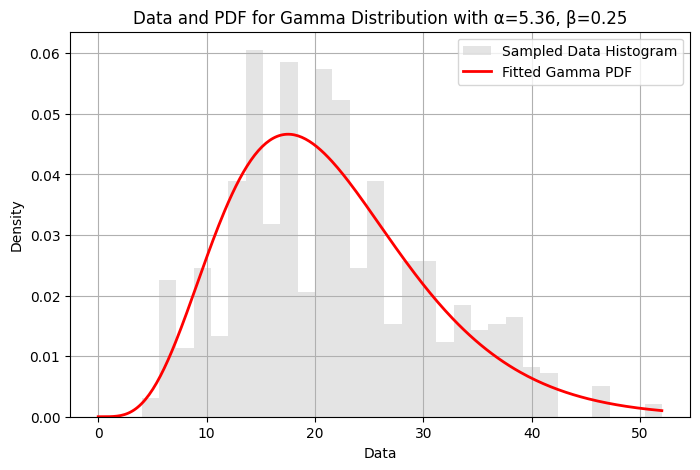

Gamma AIC : 4369.440845325373
Distribution for event V02
There are 610 assessments at this event
Estimated alpha (shape): 5.03242807382577
Estimated beta (rate): 0.21167364652438445


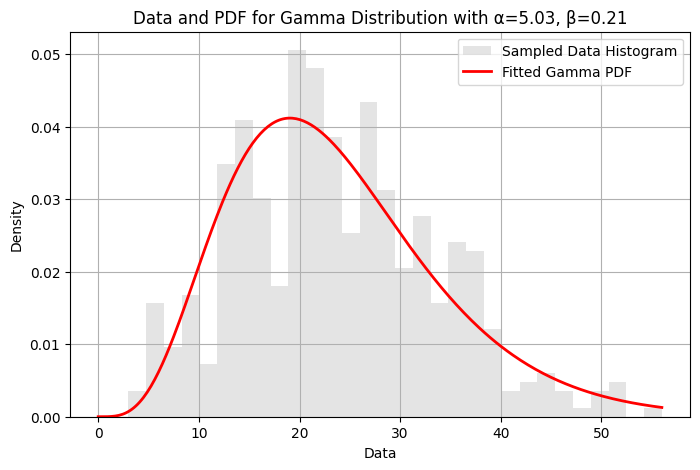

Gamma AIC : 3491.3987601747804
Distribution for event V04
There are 610 assessments at this event
Estimated alpha (shape): 5.319788242165669
Estimated beta (rate): 0.2123401380079561


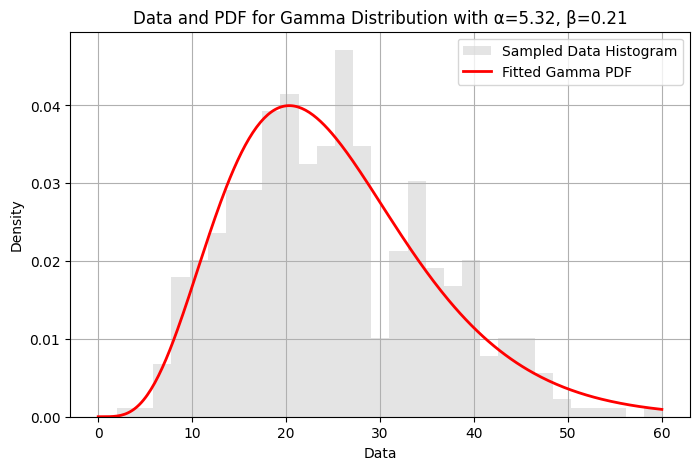

Gamma AIC : 3450.9472640788467
Distribution for event V06
There are 610 assessments at this event
Estimated alpha (shape): 5.209454597682515
Estimated beta (rate): 0.19255209862929412


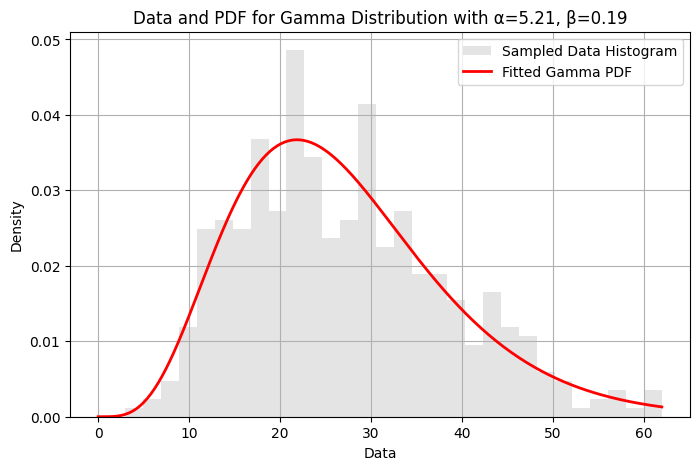

Gamma AIC : 3285.3708194437004
Distribution for event V08
There are 610 assessments at this event
Estimated alpha (shape): 5.610652365252237
Estimated beta (rate): 0.1911171129147471


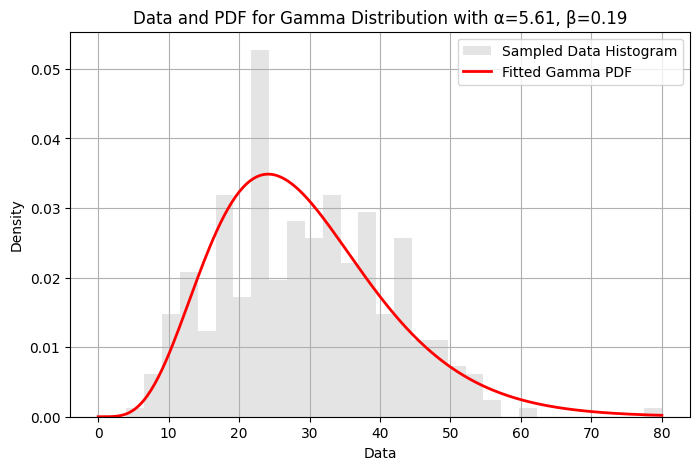

Gamma AIC : 2498.8743948222045
Distribution for event V10
There are 610 assessments at this event
Estimated alpha (shape): 6.170151436280708
Estimated beta (rate): 0.19880989957886944


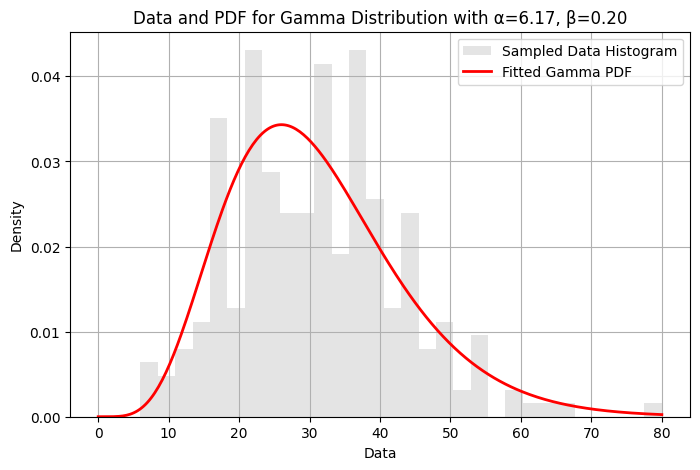

Gamma AIC : 1979.0799650824051
Distribution for event V12
There are 610 assessments at this event
Estimated alpha (shape): 5.6476966925195615
Estimated beta (rate): 0.1784695241649317


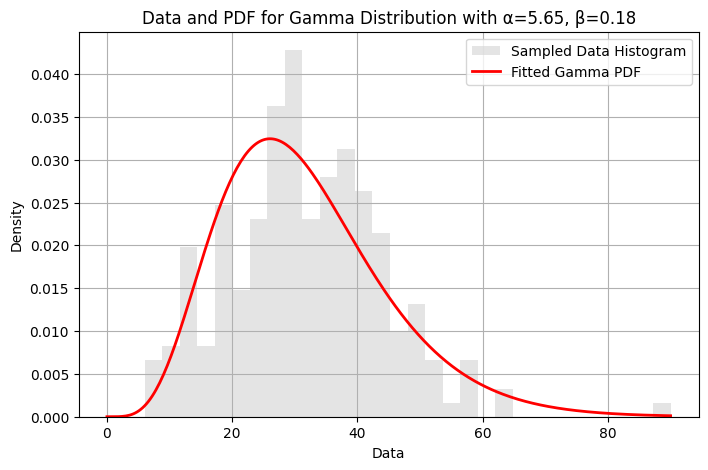

Gamma AIC : 1716.6565862528746
Distribution for event V14
There are 610 assessments at this event
Estimated alpha (shape): 6.436037265770846
Estimated beta (rate): 0.18865290111151822


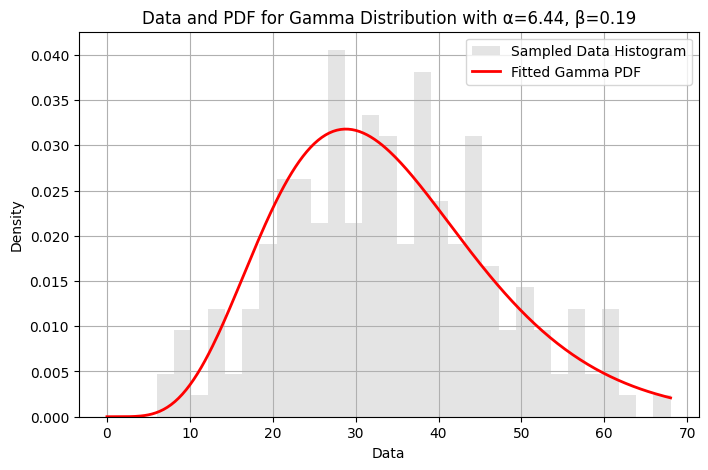

Gamma AIC : 1613.343886709608
Distribution for event V16
There are 610 assessments at this event
Estimated alpha (shape): 6.317554549708124
Estimated beta (rate): 0.16883623044611645


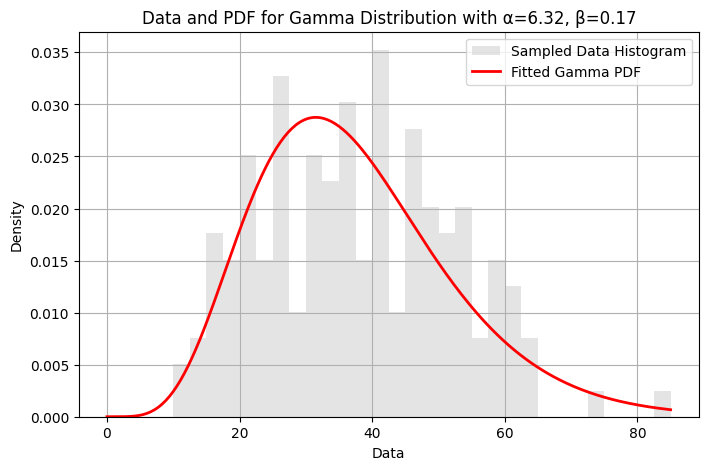

Gamma AIC : 1296.5242114228186


In [17]:
p3_label = pd.DataFrame()

for event in p3['EVENT_ID'].unique() : 
    print(f'Distribution for event {event}')
    data = p3[p3['EVENT_ID'] == event].set_index('PATNO')['NP3TOT']
    n_events = data.shape[0]
    print(f'There are {n_events} assessments at this event')
    data_filt = data[data>0]
    alpha_est , beta_est = fit_gamma_distribution(data_filt)
    aic_score = calculate_gamma_aic(data_filt, (alpha_est , beta_est))
    labels = gamma_significance_classify(data , alpha_est , beta_est , 'Worse' , thresh=0.2)
    p3_label = pd.concat([p3_label , pd.DataFrame(labels , index=data.index , columns=[event])] , axis=1)
    print(f'Gamma AIC : {aic_score}')

In [18]:
p3_label

,BL,V02,V04,V06,V08,V10,V12,V14,V16
PATNO,,,,,,,,,
3001,Not Worse,Not Worse,Not Worse,Worse,NaN,Not Worse,Not Worse,Not Worse,Not Worse
3002,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,NaN,NaN,Worse,Not Worse
3003,Worse,Worse,Worse,Worse,Worse,Worse,NaN,NaN,NaN
3006,Not Worse,Not Worse,Not Worse,NaN,NaN,NaN,NaN,NaN,NaN
3007,Not Worse,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
160231,Not Worse,Not Worse,Not Worse,Not Worse,NaN,NaN,NaN,NaN,NaN
161236,Not Worse,Not Worse,Not Worse,Not Worse,NaN,NaN,NaN,NaN,NaN
162929,Not Worse,Worse,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
p3_label.to_csv('./../Labels/PartA_Part3_Labels.csv')